| **ID**| **Name**| 
|-|-|
| 22280075     | Huynh Thao Quynh  | 
| 22280091 | Nguyen Ngoc Thanh Thu  | 

# **Final Project**

## **GIỚI THIỆU**

Trong thời đại thông tin lan truyền nhanh qua internet và mạng xã hội, việc phân biệt giữa tin thật và tin giả trở thành một thách thức lớn. Tin giả không chỉ gây nhầm lẫn mà còn ảnh hưởng tiêu cực đến niềm tin xã hội và dư luận, đặc biệt nguy hiểm trong các tình huống như đại dịch hay xung đột. Từ góc độ NLP, phát hiện tin giả là một bài toán phức tạp, đòi hỏi các kỹ thuật học máy, học sâu và mô hình hiện đại như Transformer có khả năng phân tích ngữ nghĩa và ngữ cảnh hiệu quả.

**Mục tiêu dự án**: hướng đến việc xây dựng mô hình phân loại tin thật và tin giả bằng cách áp dụng các phương pháp học máy trên hai tập dữ liệu: `MisinfoSuperset_FAKE.csv` và `MisinfoSuperset_TRUE.csv`. Mục tiêu là phát triển mô hình chính xác, đáng tin cậy, đánh giá qua các chỉ số như accuracy, precision, recall và F1-score, tuân theo quy trình học máy đầy đủ từ tiền xử lý đến đánh giá hiệu suất.


## **DATASET**

Bộ dữ liệu gốc được trích xuất từ nghiên cứu của:

> Ahmed, H., Traore, I., & Saad, S. (2017). "Detection of Online Fake News Using N-Gram Analysis and Machine Learning Techniques" (Springer LNCS 10618)

Tệp [`DataSet_Misinfo_TRUE.csv`](https://drive.google.com/file/d/1BhaOQU5wYDL8IxOzgvZM-IlgYfJf3HFD/view)

- Nguồn: Các hãng truyền thông uy tín như Reuters, The New York Times, The Washington Post, v.v.

- Nhãn: Gán nhãn `1` để biểu thị bài viết là tin thật.

Tệp [`DataSet_Misinfo_FAKE.csv`](https://drive.google.com/file/d/1aA9o8PJ-9gYAcLaaxLmXUrxlrHtArlrh/view)

- Nguồn: Các website cực hữu tại Mỹ như Redflag Newsdesk, Breitbart, Truth Broadcast Networ và một phần từ tập dữ liệu công khai của Ahmed et al. (2017) trong nghiên cứu về phân tích N-Gram và học máy.

- Nhãn: Gán nhãn `0` để biểu thị bài viết là tin giả.

## **Phương pháp tiếp cận**

Dự án áp dụng quy trình chuẩn trong lĩnh vực học máy để giải quyết bài toán phân loại tin giả, bao gồm các bước: xử lý dữ liệu, phân tích khám phá dữ liệu (EDA) để hiểu rõ đặc trưng của tập dữ liệu, sau đó tiến hành phân tích dữ liệu để hiểu rõ đặc trưng của tập dữ liệu. Tiếp theo, áp dụng nhiều phương pháp từ truyền thống đến hiện đại như TF-IDF, SVM, mô hình tuần tự (LSTM, BiLSTM), và transformer (BERT) được triển khai để tìm ra giải pháp hiệu quả nhất cho bài toán. Cuối cùng, các mô hình được đánh giá thông qua các chỉ số chuẩn như accuracy, precision, recall và F1-score nhằm so sánh và lựa chọn phương pháp hiệu quả nhất cho bài toán phát hiện tin giả.


---

## **WORK FLOW**

[01. Load Data and Preprocessing](#01-load-data-and-preprocessing)

[02. EDA - Exploratory Data Analysis](#02-eda)

[03. Prepare for model](#03-prepare-for-model)

[04. Machine Learning Model](#04-machine-learning-model)

[05 Deep Learning Model](#05-deep-learning-model)

&nbsp;&nbsp;&nbsp;&nbsp;[5.1. LSTM](#51-lstm)

&nbsp;&nbsp;&nbsp;&nbsp;[5.2. BiLSTM](#52-bilstm)

&nbsp;&nbsp;&nbsp;&nbsp;[5.3. CNN - BiLSTM](#53-cnn---bilstm)

[06. Transformer](#06-transformer)

---


# **OUR PIPELINE**

In [1]:
# Reproducibility
import os
import random
import re
import html
import string
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from tqdm import tqdm

# Set random seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plotting Libraries (EDA trực quan)
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from wordcloud import WordCloud

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.sentiment import SentimentIntensityAnalyzer
from bs4 import BeautifulSoup
from textblob import TextBlob

# Sklearn / ML
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    HalvingGridSearchCV,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from joblib import dump, load

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Embedding, Conv1D, MaxPooling1D,
    Bidirectional, LSTM, Dropout, Dense
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# PyTorch / Transformers
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

from transformers import (
    BertTokenizer,
    BertConfig,
    BertForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback
)

# Ignore warnings
warnings.filterwarnings("ignore")

## **01. Load Data and Preprocessing**

In [2]:
# Load dataset
fake_data = pd.read_csv('dataset_misinfo/DataSet_Misinfo_FAKE.csv')
real_data = pd.read_csv('dataset_misinfo/DataSet_Misinfo_TRUE.csv')

# Drop unnecessary columns and assign labels
fake_data = fake_data.drop(columns=['Unnamed: 0'])
real_data = real_data.drop(columns=['Unnamed: 0'])
fake_data['label'] = 0
real_data['label'] = 1

# Combine real and fake data 
df = pd.concat([real_data, fake_data], axis=0)
df.reset_index(drop=True, inplace=True)
df.sample(7)

,text,label
60915,ZeroHedge.com ALL CONTENT ON 'SGTREPORT.COM' A...,0
43099,As soon as news broke of notorious hatemonger ...,0
59302,"When I was reading the news this morning, I di...",0
29057,"NAIROBI, Kenya — A suicide bomb rocked the ...",1
68003,Email \nIt’s not exactly breaking news that on...,0
1182,A U.S. judge on Tuesday blocked President Dona...,1
58619,"Rusia, China y Arabia Saudita ponen en jaque l...",0


In [3]:
# Display dataset shape
print(f"Dataset shape: {df.shape}")

# Display label distribution
label_counts = df['label'].value_counts()
print(f"\nLabel distribution:\nReal (1): {label_counts[1]}\nFake (0): {label_counts[0]}")

# Check for missing values
missing = df.isnull().sum()
total_missing = missing.sum()
print("\nMissing values per column:")
print(missing)

if total_missing > 0:
    print(f"\nDropping rows with missing values...")
    df = df.dropna().reset_index(drop=True)
    print(f"New dataset shape (after drop NaN): {df.shape}")
else:
    print("\nNo missing values found.")

# Function to check for presence of HTML tags
def contains_html_tags(text):
    html_pattern = r'<[^>]+>'
    return bool(re.search(html_pattern, text))

# Check for duplicates and HTML tags
num_duplicates = df.duplicated().sum()
num_html = df['text'].apply(contains_html_tags).sum()

print(f"\nNumber of duplicate rows: {num_duplicates}")
if num_duplicates > 0:
    print(f"Dropping duplicates...")
    df = df.drop_duplicates()
    print(f"New dataset shape (after drop dup): {df.shape}")
else:
    print("\nNo duplicates found.")

print(f"\nNumber of rows containing HTML tags: {num_html}")

Dataset shape: (78617, 2)

Label distribution:
Real (1): 34975
Fake (0): 43642

Missing values per column:
text     29
label     0
dtype: int64

Dropping rows with missing values...
New dataset shape (after drop NaN): (78588, 2)

Number of duplicate rows: 9984
Dropping duplicates...
New dataset shape (after drop dup): (68604, 2)

Number of rows containing HTML tags: 202


Ở bước này, dữ liệu văn bản được làm sạch và chuẩn hóa nhằm phục vụ cho các loại mô hình khác nhau:

- **Làm sạch văn bản:** Tách riêng 2 hàm xử lý văn bản:

  - `clean_text_ml`: làm sạch phục vụ mô hình truyền thống (loại bỏ stopword, stemming,...). Những bước này giúp giảm nhiễu và số chiều của không gian đặc trưng.

  - `clean_text_transformer`: giữ cấu trúc phù hợp cho các mô hình transformer (giữ nguyên từ gốc, bỏ HTML, URL, ký tự đặc biệt,...) vì các mô hình transformer đã được pretrain dựa trên tự vựng cụ thể, phụ thuộc vào ngữ cảnh và quan hệ giữa các từ trong câu.

- **Trích xuất đặc trưng cảm xúc và hình thái học:**  

  - Dùng **VADER** để lấy điểm cảm xúc compound từ văn bản.

  - Dùng **TextBlob** để trích xuất polarity (tích cực/tiêu cực) và subjectivity (mức độ chủ quan).

- **Tính độ dài bài viết:** Sử dụng để hỗ trợ cho EDA hoặc làm feature phụ trợ trong mô hình.

Sau bước này, dữ liệu đã sẵn sàng để phân tích EDA và huấn luyện mô hình.

In [4]:
# Download necessary NLTK resources
nltk.download('stopwords')
nltk.download('vader_lexicon')

# Initialize stopwords, stemmer, and sentiment analyzer
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    """Get compound sentiment score using VADER"""
    return sia.polarity_scores(text)['compound']

def get_textblob_sentiment(text):
    """Get polarity and subjectivity using TextBlob"""
    blob = TextBlob(str(text))
    return blob.sentiment.polarity, blob.sentiment.subjectivity

def clean_text_transformer(text):
    """
    Preprocess text for transformer models.

    Removes escape characters, HTML tags, URLs, repeated special characters,
    and normalizes whitespace.
    """
    text = re.sub(r'[\t\r\n]', ' ', text)
    if re.search(r'<[^>]+>', text):
        text = BeautifulSoup(text, "html.parser").get_text()

    text = re.sub(r'(https?://)([^/\s]+)([^\s]*)', r'\2', text)
    text = re.sub(r'[_~+\-]{2,}', ' ', text)
    text = re.sub(r'\s+', ' ', text)

    return text.strip()

def clean_text_ML(text):
    """
    Preprocessing for traditional ML models

    Convert to lowercase, remove HTML, URLs, and excess characters
    Remove stopwords and apply stemming
    """
    text = str(text).lower()
    if re.search(r'<[^>]+>', text):
        text = BeautifulSoup(text, "html.parser").get_text()
    text = html.unescape(text)                                 
    text = re.sub(r'(https?://)([^/\s]+)([^\s]*)', ' ', text)
    text = re.sub(r'[_~+\-]{2,}', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    
    tokens = text.split()
    filtered = [stemmer.stem(w) for w in tokens
                if w.isalnum() and w not in stop_words]       
    
    return ' '.join(filtered)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Administra\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Administra\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [5]:
df['clean_text_trans'] = df['text'].apply(clean_text_transformer)
df['clean_text_ml'] = df['text'].apply(clean_text_ML)

df['article_length'] = df['clean_text_ml'].apply(lambda x: len(x.split()))
df['sentiment'] = df['clean_text_ml'].apply(get_sentiment)
df['textblob_sentiment'], df['textblob_subjectivity'] = zip(*df['clean_text_ml'].apply(get_textblob_sentiment))
df.head()

,text,label,clean_text_trans,clean_text_ml,article_length,sentiment,textblob_sentiment,textblob_subjectivity
0,The head of a conservative Republican faction ...,1,The head of a conservative Republican faction ...,head conserv republican faction us congress vo...,431,0.9702,0.022500,0.408500
1,Transgender people will be allowed for the fir...,1,Transgender people will be allowed for the fir...,transgend peopl allow first time enlist us mil...,222,0.5719,0.239352,0.518981
2,The special counsel investigation of links bet...,1,The special counsel investigation of links bet...,special counsel investig link russia presid 20...,250,0.5423,0.220640,0.365002
3,Trump campaign adviser George Papadopoulos tol...,1,Trump campaign adviser George Papadopoulos tol...,trump campaign advis georg papadopoulo told au...,218,0.8979,0.104685,0.278385
4,President Donald Trump called on the U.S. Post...,1,President Donald Trump called on the U.S. Post...,presid donald trump call us postal servic frid...,494,0.8979,0.003611,0.365556


In [6]:
index = 500

print("-" * 50)
print(f"TEST OUTPUT (index {index})".center(50))
print("-" * 50)

print(f"\n[1] Origin Text:\n")
print("   *", df['text'][index])

print(f"\n[2] Cleaned Text for ML model:\n")
print("   *", df['clean_text_ml'][index])

print(f"\n[3] Cleaned Text for Transformer model:\n")
print("   *", df['clean_text_trans'][index])

print("-" * 50)


--------------------------------------------------
             TEST OUTPUT (index 500)              
--------------------------------------------------

[1] Origin Text:

   * The U.S. Senate Budget Committee voted along party lines on Tuesday to send a Republican tax bill to the full Senate for a vote. The 12-to-11 vote “moves us one step closer to a simpler, fairer, and more transparent tax system,” Budget Committee Chairman Mike Enzi said in a statement.  The full Senate is expected to begin debating the tax bill and vote on it sometime this week. The Republican-controlled House of Representatives has already passed its version of a package of tax cuts.

[2] Cleaned Text for ML model:

   * us senat budget committe vote along parti line tuesday send republican tax bill full senat vote 12to11 vote us one step closer simpler fairer transpar tax budget committe chairman mike enzi said statement full senat expect begin debat tax bill vote sometim week republicancontrol hous repres alre

In [7]:
# Shuffle the dataset randomly to avoid order bias
df1 = df.sample(frac=1, random_state=42).reset_index(drop=True)
print("Dataset shape:", df1.shape)

Dataset shape: (68604, 8)


In [ ]:
# # LƯU VÀ LOAD LẠI DATA 
# df1.to_parquet("dataset_misinfo/data_after_preprocess.parquet", index=False)
# df = pd.read_parquet("dataset_misinfo/data_after_preprocess.parquet")

## **02. EDA**

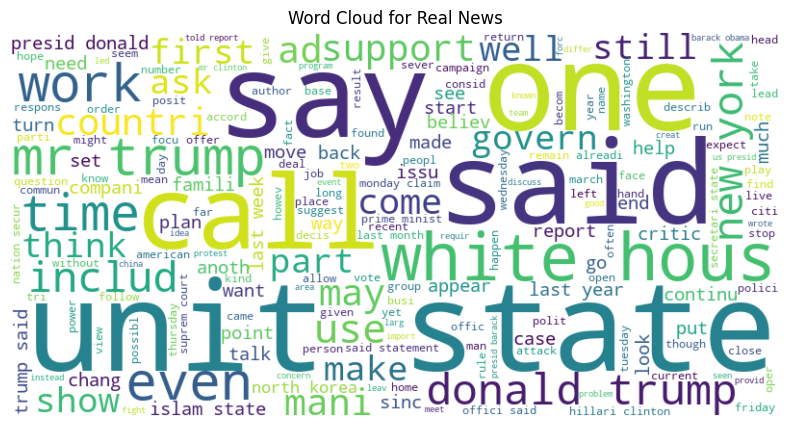

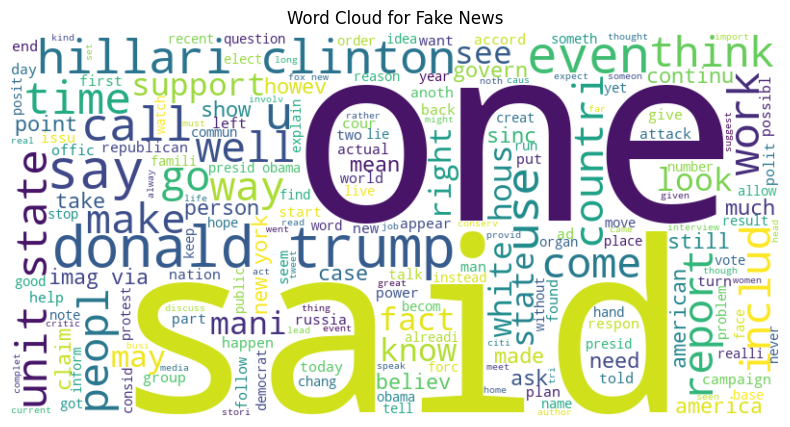

In [10]:
def plot_word_cloud(data, title):
    text_data = ' '.join(data.astype(str))
    if not text_data.strip():  
        print(f"No text data available for {title}")
        return
    
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text_data)
    
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

# Generate word clouds for Real (label=1) and Fake (label=0) news
plot_word_cloud(df1[df1['label'] == 1]['clean_text_ml'], 'Word Cloud for Real News')
plot_word_cloud(df1[df1['label'] == 0]['clean_text_ml'], 'Word Cloud for Fake News')

Hai biểu đồ đám mây từ (word cloud) cho thấy sự khác biệt rõ rệt giữa các từ khóa phổ biến trong tin tức thật (Word Cloud for Real News) và tin tức giả mạo (Word Cloud for Fake News)

**1. Word Cloud for Real News**

- **Từ khóa nổi bật**: "said", "one", "state", "call", "trump", "white", "house", "time", "mr", "include" chiếm ưu thế, với kích thước lớn hơn, cho thấy tần suất xuất hiện cao.

- **Đặc điểm**:

    - Từ vựng mang tính chính thức, báo chí chuyên nghiệp, và tuyên bố chính thức ("said", "state", "include") phản ánh văn phong của các bài viết báo chí truyền thống. 

    - Sự hiện diện của các địa danh và tổ chức: "united states", "white house", "new york", cho thấy nội dung tập trung vào tin tức chính trị - xã hội thực tế.

    - Ít mang tính cảm xúc: Không thấy nhiều từ mang tính phán xét, cảm xúc mạnh hay cực đoan.

**2. Word Cloud for Fake News**

- Từ khóa nổi bật: "one", "said", "hillary", "clinton", "trump", "state", "support", "make", "right", "think".

- **Đặc điểm**:

    - Nội dung cá nhân và thiên kiến hơn ("hillary", "clinton", "right", "attack" xuất hiện nhiều), cho thấy nội dung mang thiên hướng chính trị, cá nhân hóa và có thể chứa định kiến.

    - Nhiều từ gây tranh cãi/cảm xúc: "attack", "fake", "claim" thường được dùng để kích động hoặc đưa ra quan điểm cực đoan.

    - Tập trung vào một vài nhân vật cụ thể: "hillary clinton", "trump" xuất hiện nổi bật hơn hẳn, thể hiện xu hướng tập trung cá nhân hóa nội dung trong tin giả.

In [30]:
# Count the number of articles by label
article_count = df1['label'].value_counts().reset_index()
article_count.columns = ['label', 'count']

# Map labels 0, 1 to Fake, Real
article_count['label'] = article_count['label'].map({0: 'Fake', 1: 'Real'})

print("Number of articles by label:")
print(article_count)

# Count the number of real and fake news articles
label_counts = df1['label'].value_counts()

label_df = pd.DataFrame({'label': label_counts.index, 'count': label_counts.values})
label_df['label'] = label_df['label'].map({0: 'Fake', 1: 'Real'})  

fig = make_subplots(
    rows=1, 
    cols=2, 
    specs=[[{'type': 'pie'}, {'type': 'bar'}]],
    subplot_titles=("Pie Chart of News Labels", "Bar Plot of News Labels"),
    horizontal_spacing=0.15 
)

# Pie Chart
pie_chart = go.Pie(
    labels=label_df['label'], 
    values=label_df['count'], 
    hole=0.4,
    marker_colors=['#FF6B6B', '#4ECDC4'], 
    textinfo='percent+label',
    hoverinfo='label+percent+value'
)
fig.add_trace(pie_chart, row=1, col=1)

# Bar Plot
bar_plot = go.Bar(
    x=label_df['label'], 
    y=label_df['count'], 
    marker_color=['#FF6B6B', '#4ECDC4'],
    text=label_df['count'],
    textposition='outside'
)
fig.add_trace(bar_plot, row=1, col=2)

fig.update_layout(
    title=dict(
        text='Distribution of Real and Fake News',
        font=dict(size=20, color='#333333'),
        x=0.5,
        xanchor='center'
    ),
    font=dict(family='Arial', size=14, color='#333333'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    showlegend=True,
    legend=dict(
        title='News Type',
        x=0.85,
        y=0.9
    ),
    height=600,
    width=1100,  
    margin=dict(l=50, r=50, t=80, b=50)
)

fig.update_yaxes(
    title_text='Number of Articles',
    showgrid=True,
    gridcolor='lightgrey',
    gridwidth=1,
    tickformat=',',
    title_font=dict(size=16),
    tickfont=dict(size=14),
    range=[0, max(label_df['count']) * 1.6],
    row=1, col=2
)
fig.update_xaxes(
    title_text='News Type',
    title_font=dict(size=16),
    tickfont=dict(size=14),
    row=1, col=2
)

fig.show()

Number of articles by label:
  label  count
0  Real  34526
1  Fake  34078


**1. Phân bố dữ liệu gần như cân bằng**

- Chênh lệch giữa hai lớp chỉ 448 bài viết (~1.3%).

- Điều này rất tốt cho việc huấn luyện mô hình, vì mô hình sẽ không bị bias (thiên lệch) do dữ liệu mất cân bằng.

**2. Ý nghĩa trong huấn luyện mô hình**

- Không cần kỹ thuật cân bằng dữ liệu như oversampling (tăng dữ liệu lớp thiểu số) hay undersampling (giảm lớp đa số).

- Cho phép mô hình học phân biệt tin thật – giả dựa trên đặc trưng nội dung, không bị ảnh hưởng bởi tỷ lệ mẫu, tránh tình trạng mô hình dự đoán sai lệch về lớp đa số, phục vụ tốt cho các bài toán phân loại (classification).

In [14]:
# Calculate the average article length by label
article_length_avg = df1.groupby('label')['article_length'].mean().reset_index()
article_length_avg.columns = ['label', 'avg_length']

# Map labels 0, 1 to Fake, Real
article_length_avg['label'] = article_length_avg['label'].map({0: 'Fake', 1: 'Real'})

print("Average article length by label:")
print(article_length_avg)

# Create a bar chart
fig = go.Figure()

fig.add_trace(go.Bar(
    x=article_length_avg['label'],
    y=article_length_avg['avg_length'],
    marker_color=['#FF6B6B', '#4ECDC4'],  
    text=article_length_avg['avg_length'], 
    textposition='outside',
    texttemplate='%{text:.1f}', 
    width=0.3, 
    marker_line=dict(color='#000000', width=1)  
))

fig.update_layout(
    title=dict(
        text='Average Article Length by News Type',
        font=dict(size=20, color='#333333'),
        x=0.5,
        xanchor='center'
    ),
    xaxis_title='News Type',
    yaxis_title='Average Length (words)',
    font=dict(family='Arial', size=14, color='#333333'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    xaxis=dict(
        showgrid=False,
        title_font=dict(size=16),
        tickfont=dict(size=14)
    ),
    yaxis=dict(
        showgrid=True,
        gridcolor='lightgrey',
        gridwidth=1,
        title_font=dict(size=16),
        tickfont=dict(size=14),
        range=[0, max(article_length_avg['avg_length']) * 1.2]  
    ),
    bargap=0.05,  
    showlegend=False,
    margin=dict(l=50, r=50, t=80, b=50),
    height=500
)

fig.show()

Average article length by label:
  label  avg_length
0  Fake  235.010476
1  Real  298.769073


**1. Real News dài hơn Fake News**

- Bài viết thật có xu hướng dài hơn so với bài viết giả.

- Điều này hợp lý vì các nguồn báo chí chính thống (như Reuters, The New York Times) thường cung cấp thông tin chi tiết, được kiểm chứng kỹ lưỡng, bao gồm các thông tin nền, trích dẫn và phân tích sâu.

**2. Fake News có xu hướng ngắn và súc tích hơn**

- Tin giả thường được viết ngắn gọn, tiêu đề giật gân, nhằm nhanh chóng thu hút sự chú ý hoặc kích thích cảm xúc người đọc.

- Các bài viết này có thể cố tình tránh đi vào chi tiết, giảm khả năng kiểm chứng nội dung.

In [15]:
# Calculate mean, max, and min sentiment scores for each label
mean_sentiment = df1.groupby('label')['sentiment'].mean().reset_index()
max_sentiment = df1.groupby('label')['sentiment'].max().reset_index()
min_sentiment = df1.groupby('label')['sentiment'].min().reset_index()

summary_sentiment = pd.merge(mean_sentiment, max_sentiment, on='label', suffixes=('_mean', '_max'))
summary_sentiment = pd.merge(summary_sentiment, min_sentiment, on='label')
summary_sentiment.rename(columns={'sentiment': 'sentiment_min'}, inplace=True)

for index, row in summary_sentiment.iterrows():
    print(f"Label: {row['label']}, Mean Sentiment: {row['sentiment_mean']:.2f}, Max Sentiment: {row['sentiment_max']:.2f}, Min Sentiment: {row['sentiment_min']:.2f}")

# Create a violin plot for sentiment scores
fig = px.violin(df1, 
                 x='label', 
                 y='sentiment', 
                 box=True, 
                 points='all', 
                 title='Sentiment Polarity Distribution by Label',
                 color='label',  # Color by label
                 color_discrete_sequence=['#FF6B6B', '#4ECDC4'])  # Custom colors

fig.update_traces(meanline_visible=True)  
fig.update_layout(yaxis_title='Sentiment Score',
                  xaxis_title='News Category',
                  legend_title='Label',
                  legend=dict(x=0.85, y=0.9))  

fig.show()

Label: 0.0, Mean Sentiment: -0.06, Max Sentiment: 1.00, Min Sentiment: -1.00
Label: 1.0, Mean Sentiment: 0.02, Max Sentiment: 1.00, Min Sentiment: -1.00


**Cảm xúc của Fake News có xu hướng tiêu cực hơn**
  
- Giá trị trung bình là âm (-0.06) cho thấy nhiều bài viết giả có xu hướng mang tính tiêu cực hơn, có thể mang tính công kích, giật gân, hoặc gây hoang mang.

**Real News gần trung tính hoặc hơi tích cực**

- Với điểm trung bình là +0.02, nội dung của tin thật nhìn chung có thiên hướng trung lập hoặc mô tả khách quan, điều này phù hợp với văn phong báo chí chuyên nghiệp.

**Cả hai loại đều có phân bố rộng**

- Dải sentiment kéo dài từ -1 đến 1 cho cả hai loại, nghĩa là có sự đa dạng cảm xúc trong cả tin thật lẫn tin giả.

- Tuy nhiên, biểu đồ violin cho Fake News phình to ở các cực trị, thể hiện nhiều bài viết có cảm xúc rất mạnh (rất tích cực hoặc rất tiêu cực), trong khi Real News có xu hướng tập trung gần vùng trung tâm hơn.

-> Sentiment score có thể là một feature hữu ích, giúp mô hình nhận biết xu hướng cảm xúc bất thường trong Fake News. Tuy nhiên, nó không đủ mạnh để phân biệt hoàn toàn, nên nên dùng kết hợp với các đặc trưng khác như từ vựng, độ dài, hoặc cấu trúc ngữ pháp.

In [16]:
# Calculate mean, max, and min sentiment scores for each label
mean_sentiment = df1.groupby('label')['textblob_sentiment'].mean().reset_index()
max_sentiment = df1.groupby('label')['textblob_sentiment'].max().reset_index()
min_sentiment = df1.groupby('label')['textblob_sentiment'].min().reset_index()

summary_sentiment = pd.merge(mean_sentiment, max_sentiment, on='label', suffixes=('_mean', '_max'))
summary_sentiment = pd.merge(summary_sentiment, min_sentiment, on='label')
summary_sentiment.rename(columns={'textblob_sentiment': 'textblob_sentiment_min'}, inplace=True)

for index, row in summary_sentiment.iterrows():
    print(f"Label: {row['label']}, Mean Sentiment: {row['textblob_sentiment_mean']:.2f}, Max Sentiment: {row['textblob_sentiment_max']:.2f}, Min Sentiment: {row['textblob_sentiment_min']:.2f}")

# Create the violin plot
fig = px.violin(df1, x='label', y='textblob_sentiment', box=True, points='all',
                 title='TextBlob Sentiment Polarity Distribution by Label',
                 color='label',  
                 color_discrete_sequence=px.colors.qualitative.Set2)

for index, row in summary_sentiment.iterrows():
    # Annotate mean score
    fig.add_annotation(
        x=row['label'],
        y=row['textblob_sentiment_mean'],
        text=f'Mean: {row["textblob_sentiment_mean"]:.2f}',  
        showarrow=True,
        arrowhead=2,
        ax=0,
        ay=-40,  
        font=dict(color='black', size=12)
    )

    fig.add_annotation(
        x=row['label'],
        y=row['textblob_sentiment_max'],
        text=f'Max: {row["textblob_sentiment_max"]:.2f}',  
        showarrow=True,
        arrowhead=2,
        ax=0,
        ay=-20,
        font=dict(color='red', size=12) 
    )
    # Annotate min score
    fig.add_annotation(
        x=row['label'],
        y=row['textblob_sentiment_min'],
        text=f'Min: {row["textblob_sentiment_min"]:.2f}',  
        showarrow=True,
        arrowhead=2,
        ax=0,
        ay=0, 
        font=dict(color='blue', size=12) 
    )

fig.update_layout(
    legend_title_text='Label',
    yaxis_title='TextBlob Sentiment Polarity',
    xaxis_title='Label',
    template='plotly_white'  
)

fig.show()

Label: 0.0, Mean Sentiment: 0.07, Max Sentiment: 1.00, Min Sentiment: -1.00
Label: 1.0, Mean Sentiment: 0.07, Max Sentiment: 1.00, Min Sentiment: -0.88


**1. Điểm sentiment trung bình giống nhau cho cả hai loại**

- Cả Fake và Real News đều có mean sentiment = 0.07, cho thấy TextBlob không phân biệt rõ ràng được cảm xúc tổng thể giữa hai loại bài viết.

- Điều này gợi ý rằng mô hình sentiment của TextBlob có thể quá đơn giản hoặc không nhạy cảm với ngữ cảnh chính trị/xã hội phức tạp trong các bài báo.

**2. Dải giá trị rộng và cân đối ở cả hai nhãn**

- Cả hai nhãn đều có phân bố từ gần -1 đến 1. Fake News có điểm cực tiểu (-1.00) rộng hơn một chút so với Real News (-0.88), nhưng chênh lệch nhỏ.

- Không có dấu hiệu thiên lệch rõ rệt về cực trị tích cực/tiêu cực giữa hai nhóm.

**3. Dạng phân bố tương tự nhau**

- Hai biểu đồ violin gần như đối xứng, với đa số điểm sentiment gần vùng 0 (trung tính). Cho thấy phần lớn nội dung cả tin thật lẫn giả không mang cảm xúc cực đoan, hoặc TextBlob khó bắt được các biểu cảm ẩn hay gián tiếp.

In [17]:
# Function to get top N words, excluding stopwords
def get_top_n_words(corpus, n=10):
    words = ' '.join(corpus).split()
    words = [word for word in words if word.isalpha() and word.lower() not in stop_words]
    common_words = Counter(words)
    return common_words.most_common(n)

# Function to plot top N words 
def plot_top_n_words(data, title, n=10, base_color='#000000', highlight_color='#000000'):
    top_words = get_top_n_words(data['clean_text_ml'], n)
    if not top_words:  
        print(f"No significant words to plot for {title}")
        return
    
    words, counts = zip(*top_words)
    
    counts = list(counts)
    words = list(words)

    print(f"Top words for {title}:")
    for word, count in zip(words, counts):
        print(f"{word}: {count}")
    
    max_count_index = counts.index(max(counts))

    colors = [highlight_color if i == max_count_index else base_color for i in range(len(counts))]

    fig = px.bar(x=words, y=counts, 
                 title=title, 
                 labels={'x': 'Words', 'y': 'Counts'},
                 color=words,  
                 color_discrete_map={word: color for word, color in zip(words, colors)},
                 text=counts, 
                 text_auto=True)  

    fig.update_traces(textposition='outside')
    
    fig.update_layout(
        title=dict(text=title, 
                   font=dict(size=20, color='#333333'), 
                   x=0.5, 
                   xanchor='center'),
        xaxis_title='Words',
        yaxis_title='Counts',
        font=dict(family='Arial', size=14, color='#333333'),
        plot_bgcolor='white',
        paper_bgcolor='white',
        xaxis=dict(
            showgrid=False, 
            title_font=dict(size=16),
            tickfont=dict(size=14),
            tickangle=45  
        ),
        yaxis=dict(
            showgrid=True, 
            gridcolor='lightgrey', 
            gridwidth=1,
            title_font=dict(size=16),
            tickfont=dict(size=14)
        ),
        showlegend=False,
        margin=dict(l=50, r=50, t=80, b=50),
        height=500
    )
    
    fig.show()

real_base_color = '#4ECDC4'  
real_highlight_color = '#2A7C73' 
fake_base_color = '#FF6B6B'  
fake_highlight_color = '#B53030'

In [18]:
# Plot top 10 words for Real and Fake news 
plot_top_n_words(df1[df1['label'] == 1], 'Top 10 Words in Real News', n=10, 
                 base_color=real_base_color, highlight_color=real_highlight_color)
plot_top_n_words(df1[df1['label'] == 0], 'Top 10 Words in Fake News', n=10, 
                 base_color=fake_base_color, highlight_color=fake_highlight_color)

Top words for Top 10 Words in Real News:
said: 166378
trump: 75739
mr: 70400
state: 60537
would: 56008
presid: 47034
us: 45676
year: 39836
one: 39010
new: 38366


Top words for Top 10 Words in Fake News:
trump: 81548
peopl: 37759
us: 36534
said: 35349
one: 34873
state: 33808
would: 33419
clinton: 30606
presid: 30500
like: 29915


**Điểm chung giữa hai loại**

- Một số từ xuất hiện nhiều trong cả hai tập như: “trump”, “said”, “us”, “state”, “would”, “presid”, “one”. Cho thấy hai loại tin tức đều đề cập đến các chủ đề tương tự như chính trị, quốc gia, nhân vật công chúng.

**Khác biệt chính**
|Real News	| Fake News |
| - | - |
|“said” là từ phổ biến nhất – phản ánh phong cách trích dẫn trong báo chí truyền thống.	 | “trump” là từ phổ biến nhất – thể hiện sự tập trung chủ yếu vào cá nhân, thường là để phê phán hay tuyên truyền.|
|Có từ “mr” mang tính trang trọng.	| Có từ “peopl” (đã được stemming từ “people”) cho thấy văn phong gần gũi hoặc đại chúng. |
|“year, new” → đề cập thời gian hoặc bối cảnh sự kiện.	| “clinton, like” → tập trung cá nhân và cảm tính nhiều hơn. |

**Ý nghĩa phân loại**

- Fake News có xu hướng tập trung vào cá nhân hóa và từ ngữ cảm tính hơn.

- Real News ưu tiên trình bày trung lập và có cấu trúc chuyên nghiệp hơn (nhiều trích dẫn, danh xưng trang trọng).

## **03. Prepare for model**

In [ ]:
# X = df1.drop(columns=['label'])
# y = df1['label']

# X_train, X_temp, y_train, y_temp = train_test_split(
#     X, y,
#     test_size=0.2, 
#     stratify=y,
#     random_state=42
# )

# X_val, X_test, y_val, y_test = train_test_split(
#     X_temp, y_temp,
#     test_size=0.5,
#     stratify=y_temp,
#     random_state=42
# )
# print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}")

Train: 54,883  |  Val: 6,860  |  Test: 6,861


In [ ]:
def evaluate_model(model_name, y_test, y_pred):
    # Metric
    print(f"--------------- {model_name} Model ---------------")
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.5f}")
    print(f"Precision: {precision_score(y_test, y_pred):.5f}")
    print(f"Recall: {recall_score(y_test, y_pred):.5f}")
    print(f"F1 Score: {f1_score(y_test, y_pred):.5f}")

    # Classification report
    print("\nClassification Report")
    print(classification_report(y_test, y_pred))

    print('-'*30)
    print(f"Predict results (ground truth vs predicted)")
    df_pred = pd.DataFrame({
        'y_test': y_test,
        'Predicted': y_pred.reshape(-1)
    })
    # Xem ngẫu nhiên 10 sample
    display(df_pred.sample(10))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

def visualize_loss(model_name, train_loss, val_loss):
    plt.figure(figsize=(8, 5))
    plt.plot(train_loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.title(f'Training vs. Validation Loss - {model_name} Model')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## **04. Machine Learning Model**

In [1]:
import warnings, joblib, matplotlib.pyplot as plt, seaborn as sns
warnings.filterwarnings("ignore", category=UserWarning)

from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, accuracy_score, f1_score, confusion_matrix
)
import pandas as pd

# ======================================================================
# 1. Load & shuffle data
# ======================================================================
PARQUET = Path("dataset_misinfo/data_after_preprocess.parquet")
df1 = pd.read_parquet(PARQUET)

assert {"clean_text_ml", "label"} <= set(df1.columns), \
       "Thiếu cột 'clean_text_ml' hoặc 'label'!"

df1 = df1.sample(frac=1, random_state=42).reset_index(drop=True)
print("Dataset shape:", df1.shape)

Dataset shape: (78588, 7)


In [2]:
X = df1.drop(columns=["label"])
y = df1["label"]

# Split: 80 % train - 10 % val - 10 % test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42
)
print(f"Train: {len(X_train):,}  |  Val: {len(X_val):,}  |  Test: {len(X_test):,}")

Train: 62,870  |  Val: 7,859  |  Test: 7,859


In [3]:
X_train_txt = X_train["clean_text_ml"]
X_val_txt   = X_val["clean_text_ml"]
X_test_txt  = X_test["clean_text_ml"]

In [4]:
pipelines = {
    "TFIDF": Pipeline([
        ("vect", TfidfVectorizer(
            stop_words="english",
            strip_accents="unicode",
            sublinear_tf=True
        )),
        ("clf", LinearSVC(class_weight="balanced", random_state=42))
    ]),
    "COUNT": Pipeline([
        ("vect", CountVectorizer(
            stop_words="english",
            strip_accents="unicode"
        )),
        ("clf", LinearSVC(class_weight="balanced", random_state=42))
    ]),
}

param_grids = {
    "TFIDF": {
        "vect__ngram_range": [(1, 1), (1, 2)],
        "vect__min_df": [3, 5],
        "vect__max_df": [0.8, 0.9],
        "clf__C": [0.25, 0.5, 1, 2],
    },
    "COUNT": {
        "vect__ngram_range": [(1, 1), (1, 2)],
        "vect__min_df": [3, 5],
        "vect__max_df": [0.8, 0.9],
        "clf__C": [0.25, 0.5, 1, 2],
    },
}

best_name, best_f1, best_pipe = None, -1, None


for name, pipe in pipelines.items():
    print(f"\n=== GridSearch for {name} ===")
    gs = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="f1",
        verbose=1,
        n_jobs=-1,
    )
    gs.fit(X_train_txt, y_train)

    print("Best CV params:", gs.best_params_)
    print("Best CV F1   :", gs.best_score_)

    val_pred = gs.predict(X_val_txt)
    f1_val   = f1_score(y_val, val_pred)
    acc_val  = accuracy_score(y_val, val_pred)
    print(f"Val Accuracy: {acc_val:.4f} | Val F1: {f1_val:.4f}")
    print(classification_report(y_val, val_pred, digits=4))

    if f1_val > best_f1:
        best_name, best_f1, best_pipe = name, f1_val, gs.best_estimator_

print(f"\nBest on Val: {best_name} | F1 = {best_f1:.4f}")



=== GridSearch for TFIDF ===
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best CV params: {'clf__C': 2, 'vect__max_df': 0.8, 'vect__min_df': 5, 'vect__ngram_range': (1, 2)}
Best CV F1   : 0.9616893326457088
Val Accuracy: 0.9701 | Val F1: 0.9661
              precision    recall  f1-score   support

           0     0.9661    0.9805    0.9733      4364
           1     0.9752    0.9571    0.9661      3495

    accuracy                         0.9701      7859
   macro avg     0.9707    0.9688    0.9697      7859
weighted avg     0.9702    0.9701    0.9701      7859


=== GridSearch for COUNT ===
Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best CV params: {'clf__C': 0.25, 'vect__max_df': 0.8, 'vect__min_df': 5, 'vect__ngram_range': (1, 2)}
Best CV F1   : 0.9380630747190762
Val Accuracy: 0.9508 | Val F1: 0.9439
              precision    recall  f1-score   support

           0     0.9464    0.9661    0.9561      4364
           1     0.9565    0.9316  

In [5]:
X_train_full_txt = pd.concat([X_train_txt, X_val_txt])
y_train_full     = pd.concat([y_train, y_val])

best_pipe.fit(X_train_full_txt, y_train_full)

y_pred_test = best_pipe.predict(X_test_txt)
print("\n=== Test set performance ===")
print(classification_report(y_test, y_pred_test, digits=4))


=== Test set performance ===
              precision    recall  f1-score   support

           0     0.9688    0.9810    0.9748      4365
           1     0.9759    0.9605    0.9681      3494

    accuracy                         0.9719      7859
   macro avg     0.9723    0.9707    0.9715      7859
weighted avg     0.9719    0.9719    0.9719      7859



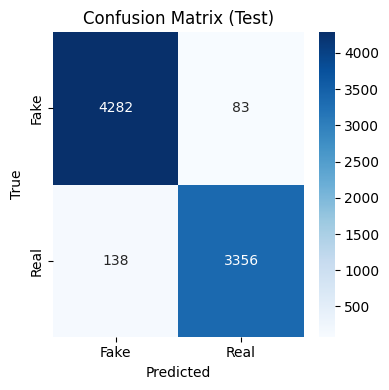

In [6]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(4, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Fake", "Real"],
    yticklabels=["Fake", "Real"],
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Test)")
plt.tight_layout()
plt.show()

In [7]:
MODEL_PATH = Path("dataset_misinfo/best_fake_news_model_gridsearch.joblib")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_pipe, MODEL_PATH)
print("Model saved to", MODEL_PATH.resolve())

Model saved to D:\Fake-News-Detector\dataset_misinfo\best_fake_news_model_gridsearch.joblib


In [8]:
PRED_CSV = Path("dataset_misinfo/predictions_test_gridsearch.csv")
pred_df = pd.DataFrame(
    {
        "text": X_test_txt.values,
        "true_label": y_test.values,
        "pred_label": y_pred_test,
    }
)
pred_df.to_csv(PRED_CSV, index=False)
print("Predictions saved to", PRED_CSV.resolve())

Predictions saved to D:\Fake-News-Detector\dataset_misinfo\predictions_test_gridsearch.csv


## **05. Deep Learning Model**

In [ ]:
X_train_dl = X_train['clean_text_ml']
X_test_dl = X_test['clean_text_ml']
X_val_dl = X_val['clean_text_ml']

In [ ]:
# Phân tích từ hiếm
threshold = 5
tmp_tokenizer = Tokenizer()
tmp_tokenizer.fit_on_texts(X_train_dl)

total_words = len(tmp_tokenizer.word_counts)
rare_words = sum(1 for count in tmp_tokenizer.word_counts.values() if count < threshold)
rare_freq = sum(count for count in tmp_tokenizer.word_counts.values() if count < threshold)
total_freq = sum(tmp_tokenizer.word_counts.values())

print(f"% of rare words in vocabulary: {rare_words / total_words * 100:.2f}%")
print(f"Total coverage of rare words: {rare_freq / total_freq * 100:.2f}%")

In [ ]:
MAX_LEN = 250
embedding_dim = 256
latent_dim = 300

# Tokenizer 
vocab_size = total_words - rare_words
tokenizer_dl = Tokenizer(num_words=vocab_size)
tokenizer_dl.fit_on_texts(X_train_dl)

# Sequence & padding
X_train_seq = tokenizer_dl.texts_to_sequences(X_train_dl)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test_dl)
X_val_seq = tokenizer_dl.texts_to_sequences(X_val_dl)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_LEN, padding='post')

In [ ]:
def init_model(model_name, dropout=0.3, filters=32, kernel_size=5):
    model = Sequential()
    model.add(Embedding(input_dim=vocab_size + 1, output_dim=embedding_dim, input_shape=(MAX_LEN,), trainable=True))
    model.add(Dropout(dropout))

    if model_name == 'lstm':
        model.add(LSTM(latent_dim, return_sequences=False))

    if model_name == 'bilstm':
        model.add(Bidirectional(LSTM(latent_dim, return_sequences=False)))
    
    elif model_name == 'cnn_bilstm':
        # CNN layer
        model.add(Conv1D(filters, kernel_size, activation='relu', strides=1, padding='same'))
        model.add(MaxPooling1D())

        model.add(Conv1D(filters, kernel_size, activation='relu',  strides=1, padding='same'))
        model.add(MaxPooling1D())

        # BiLSTM layer
        model.add(Bidirectional(LSTM(latent_dim, return_sequences=False)))

    else:
        raise ValueError("Unknown model_name. Choose from: 'lstm', 'bilstm', 'cnn_bilstm'")
    
    model.add(Dropout(dropout))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    model.summary()
    return model


In [ ]:
def train_and_save_model(model_name, model):
    print(f"\n----- Training {model_name.upper()} -----")

    # Tạo đường dẫn checkpoint riêng cho từng mô hình
    checkpoint_path = f"checkpoint_{model_name}.h5"

    # Callback lưu mô hình tốt nhất
    checkpoint = ModelCheckpoint(
        filepath=checkpoint_path,
        monitor='val_loss',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )

    # Early stopping
    early_stopping = EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )

    # Huấn luyện
    history = model.fit(
        X_train_pad, y_train,
        validation_data=(X_val_pad, y_val),
        epochs=20,
        batch_size=128,
        callbacks=[checkpoint, early_stopping]
    )

    return model, history, checkpoint_path


### **5.1. LSTM**

In [ ]:
model_lstm = init_model('lstm')

In [ ]:
model_lstm, history_lstm, path_lstm = train_and_save_model('lstm', model_lstm)

In [ ]:
visualize_loss('LSTM', history_lstm.history['loss'], history_lstm.history['val_loss'])

In [ ]:
# Load best model and predict
best_lstm = load_model(path_lstm)
y_prob_lstm = best_lstm.predict(X_test_pad)
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

evaluate_model('LSTM', y_test, y_pred_lstm)

### **5.2. BiLSTM**

In [ ]:
model_bilstm = init_model('bilstm')

In [ ]:
model_bilstm, history_bilstm, path_bilstm = train_and_save_model('bilstm', model_bilstm)

In [ ]:
visualize_loss('BiLSTM', history_bilstm.history['loss'], history_bilstm.history['val_loss'])

In [ ]:
# Load best model and predict
best_bilstm = load_model(path_bilstm)
y_prob_bilstm = best_bilstm.predict(X_test_pad)
y_pred_bilstm = (y_prob_bilstm >= 0.5).astype(int)

evaluate_model('BiLSTM', y_test, y_pred_bilstm)

### **5.3. CNN - BiLSTM**

In [ ]:
model_combine = init_model('cnn_bilstm')

In [ ]:
model_combine, history_combine, path_combine = train_and_save_model('cnn_bilstm', model_combine)

In [ ]:
visualize_loss('CNN - BiLSTM', history_combine.history['loss'], history_combine.history['val_loss'])

In [ ]:
# Load best model and predict
best_combine = load_model(path_combine)
y_prob_combine = best_combine.predict(X_test_pad)
y_pred_combine = (y_prob_combine >= 0.5).astype(int)

evaluate_model('CNN - BiLSTM', y_test, y_pred_combine)

## **06. Transformer**

In [ ]:
# ------------ 1. Tokenizer ------------
def tokenize_data(texts, model_name='bert-base-uncased', max_length=256):
    tokenizer = BertTokenizer.from_pretrained(model_name)

    encoding = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=max_length
    )
    return encoding

In [ ]:
# ------------ 2. Dataset ------------
class FakeNewDataset(Dataset):
    def __init__(self, encodings, labels=None):
        super().__init__()
        self.encodings = encodings
        self.labels = labels 
    
    def __len__(self):
        return len(self.encodings['input_ids'])
    
    def __getitem__(self, index):
        item = {key: torch.tensor(val[index]) for key, val in self.encodings.items()}
        if self.labels is not None:
            item['labels'] = torch.tensor(self.labels[index])
        return item

In [ ]:
# ------------ 3. Model ------------
def get_model(model_name='bert-base-uncased', num_labels=2):
    config = BertConfig.from_pretrained('bert-base-uncased', num_labels=num_labels, hidden_dropout_prob=0.5, attention_probs_dropout_prob=0.5)
    model = BertForSequenceClassification.from_pretrained(
        model_name,
        config=config
    )
    return model

In [ ]:
learning_rate = 2e-5
n_epoch = 5
patience = 2
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class Trainer:
    def __init__(self, model, train_loader, val_loader, lr, epochs, patience, device):
        self.model = model
        self.train_loader = train_loader
        self.val_loader = val_loader
        self.epochs = epochs
        self.device = device
        self.patience = patience
        self.train_loss_history = []
        self.val_loss_history = []
        self.optimizer = AdamW(self.model.parameters(), lr=lr)
        self.model.to(self.device)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        loop = tqdm(self.train_loader, desc="\tTraining", leave=False)
        for batch in loop:
            batch = {k: v.to(self.device) for k, v in batch.items()}
            outputs = self.model(**batch)
            loss = outputs.loss
            loss.backward()
            self.optimizer.step()
            self.optimizer.zero_grad()

            total_loss += loss.item()
            loop.set_postfix(loss=loss.item())
        avg_loss = total_loss / len(self.train_loader)
        return avg_loss

    def evaluate(self):
        self.model.eval()
        all_preds = []
        all_labels = []
        total_loss = 0.0

        loop = tqdm(self.val_loader, desc="\tEvaluating", leave=False)
        with torch.no_grad():
            for batch in loop:
                batch = {k: v.to(self.device) for k, v in batch.items()}
                outputs = self.model(**batch)
                logits = outputs.logits
                preds = torch.argmax(logits, dim=1)

                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(batch['labels'].cpu().numpy())
                loss = outputs.loss
                total_loss += loss.item()
                loop.set_postfix(loss=loss.item())
        avg_loss = total_loss / len(self.val_loader)
        acc = accuracy_score(all_labels, all_preds)
        return acc, avg_loss

    def train(self):
        best_loss = float('inf')
        patience_counter = 0.0
        for epoch in range(1, self.epochs+1):
            print(f"Epoch {epoch}/{self.epochs}")
            train_loss = self.train_epoch()
            val_acc, val_loss = self.evaluate()

            self.train_loss_history.append(train_loss)
            self.val_loss_history.append(val_loss)

            print(f"\tTrain loss = {train_loss:.5f} | val_loss = {val_loss:.5f}")
            print(f"\tVal accuracy: {val_acc}")

            if val_loss < best_loss:
                best_loss = val_loss
                patience_counter = 0
                torch.save(self.model.state_dict(), f"{self.model.__class__.__name__}_best.pt")
            else:
                patience_counter += 1
                if patience_counter >= self.patience:
                    print("Early stopping triggered.")
                    break

    def inference_model(self, dataloader):
        self.model.eval()
        all_preds = []

        with torch.no_grad():
            for batch in tqdm(dataloader, desc="Inferencing"):
                batch = {k: v.to(self.device) for k, v in batch.items() if k != 'labels'}
                outputs = self.model(**batch)
                logits = outputs.logits
                preds = torch.argmax(logits, dim=1)
                all_preds.extend(preds.cpu().numpy())

        return all_preds

In [ ]:
# -------- 5. Prepare data --------
X_train_trans, X_val_trans, X_test_trans = [
    df['clean_text_trans'].tolist() for df in [X_train, X_val, X_test]
]

y_train_trans, y_val_trans, y_test_trans = [
    y.tolist() for y in [y_train, y_val, y_test]
]

train_encodings = tokenize_data(X_train_trans)
val_encodings = tokenize_data(X_val_trans)
test_encodings = tokenize_data(X_test_trans)

train_dataset = FakeNewDataset(train_encodings, y_train_trans)
val_dataset = FakeNewDataset(val_encodings, y_val_trans)
test_dataset = FakeNewDataset(test_encodings)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [ ]:
model_bert = get_model()

print(f"-"*50)
print("TRAINING MODEL: BERT".center(50))
print(f"-"*50)
trainer = Trainer(
    model_bert, 
    train_loader, 
    val_loader, 
    lr=learning_rate,
    epochs=n_epoch, 
    patience=patience, 
    device=device
)
trainer.train()

In [ ]:
visualize_loss(
    model_name="BERT", 
    train_loss=trainer.train_loss_history, 
    val_loss=trainer.val_loss_history
)

In [ ]:
# Load best model
model_bert.load_state_dict(torch.load("BertForSequenceClassification_best.pt"))
model_bert.to(device)

In [ ]:
# Inference
print(f"-"*50)
print(f"\tINFERENCE MODEL")
print(f"-"*50)

y_pred_bert = trainer.inference_model(test_loader)
print(classification_report(y_test, y_pred_bert))